In [3]:
import tensorflow as tf

In [4]:
# Load in the data
from sklearn.datasets import load_breast_cancer

In [5]:
# load the data
data = load_breast_cancer()

In [6]:
# check the type of 'data'
type(data)

sklearn.utils._bunch.Bunch

In [7]:
# 'data' (the attribute) means the input data
data.data.shape
# it has 569 samples, 30 features

(569, 30)

In [8]:
#  'targets'
data.target
# note how the targets are just 0s and 1s
# normally, when you have K targets, they are labeled 0..K-1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [9]:
# normally we would put all of our imports at the top
# but this lets us tell a story
from sklearn.model_selection import train_test_split


# split the data into train and test sets
# this lets us simulate how our model will perform in the future
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33)
N, D = X_train.shape

In [11]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

In [13]:
# Build the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(64, input_shape=(D,), activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [15]:
# Train the model
batch_size = 32

# Old way
# r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)

# New way
r = model.fit(
    train_dataset.batch(batch_size),
    validation_data=test_dataset.batch(batch_size),
    epochs=15)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.7375 - loss: 0.5571 - val_accuracy: 0.8298 - val_loss: 0.4305
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8924 - loss: 0.3487 - val_accuracy: 0.9043 - val_loss: 0.3034
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9344 - loss: 0.2561 - val_accuracy: 0.9149 - val_loss: 0.2445
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9423 - loss: 0.2075 - val_accuracy: 0.9202 - val_loss: 0.2120
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9475 - loss: 0.1765 - val_accuracy: 0.9309 - val_loss: 0.1912
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9501 - loss: 0.1545 - val_accuracy: 0.9255 - val_loss: 0.1761
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9528 - loss: 0.1378 - val_accuracy: 0.9362 - val_loss: 0.1646
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9606 - loss: 0.1247 - val_accuracy: 0.9362 - val_lo

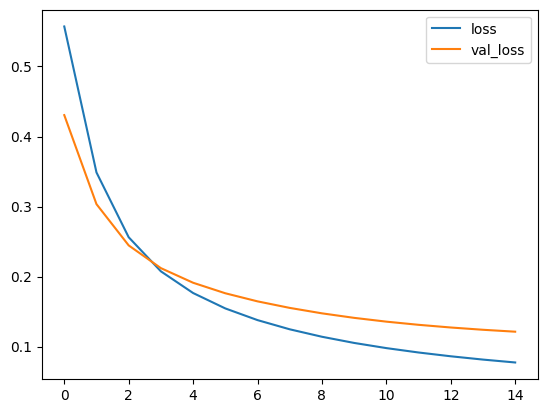

In [16]:
# Plot loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

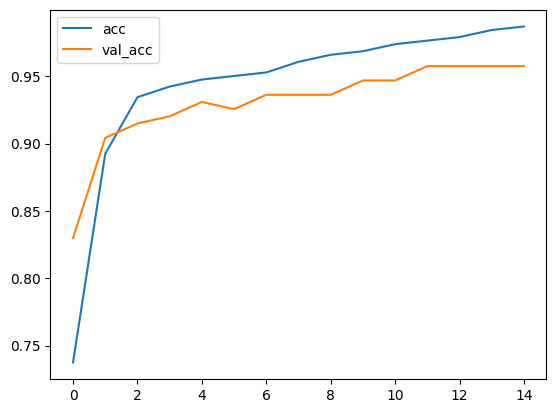

In [17]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [18]:
# Evaluate the model
print(model.evaluate(test_dataset.batch(batch_size)))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9574 - loss: 0.1213
[0.12126348167657852, 0.957446813583374]


In [20]:
#Example usage of batch method
dataset = tf.data.Dataset.from_tensor_slices([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Batch elements into groups of size 3
batched_dataset = dataset.batch(3)

# Iterate over batches
for batch in batched_dataset:
    print(batch.numpy())

[1 2 3]
[4 5 6]
[7 8 9]
[10]


In [21]:
shuffled = dataset.shuffle(buffer_size=3)
shuffled

<_ShuffleDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>

In [22]:
batched_shuffled = shuffled.batch(3)

for batch in batched_shuffled:
  print(batch.numpy())


[3 1 5]
[4 7 8]
[9 6 2]
[10]


In [24]:
# Every time you loop through the batch, it shuffles again!
for batch in batched_shuffled:
  print(batch.numpy())

[1 2 5]
[6 3 7]
[ 8 10  4]
[9]


In [25]:
# Apply a function to every sample in the dataset
transformed = dataset.map(lambda x: x / 2)
batched_transformed = transformed.batch(3)

for batch in batched_transformed:
  print(batch.numpy())

[0.5 1.  1.5]
[2.  2.5 3. ]
[3.5 4.  4.5]
[5.]
